
# Plot electrode positions

.. currentmodule:: eeg_positions


We need to import some functions.



In [2]:
!pip install eeg_positions

In [3]:
from eeg_positions import get_elec_coords, plot_coords

Let's start with the basic 10-20 system in two dimensions:



In [4]:
coords = get_elec_coords(
    system="1020",
    dim="2d",
)

This function returns a ``pandas.DataFrame`` object:



In [5]:
coords.head()

,label,x,y
0,Cz,0.0,0.000000
1,Fpz,0.0,0.726585
2,Fz,0.0,0.324931
3,Pz,0.0,-0.324931
4,Oz,0.0,-0.726585


Now let's plot these coordinates.
We can supply some style arguments to :func:`eeg_positions.plot_coords` to control
the color of the electrodes and the text annotations.



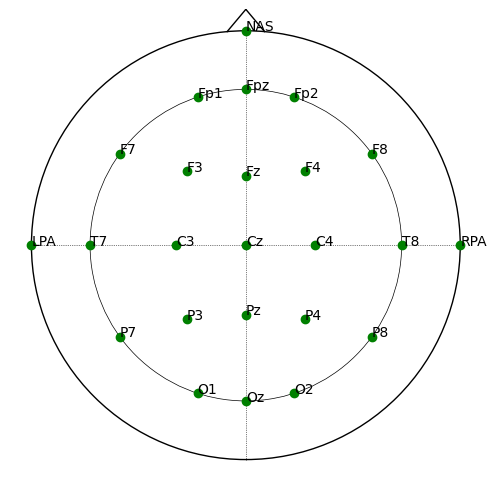

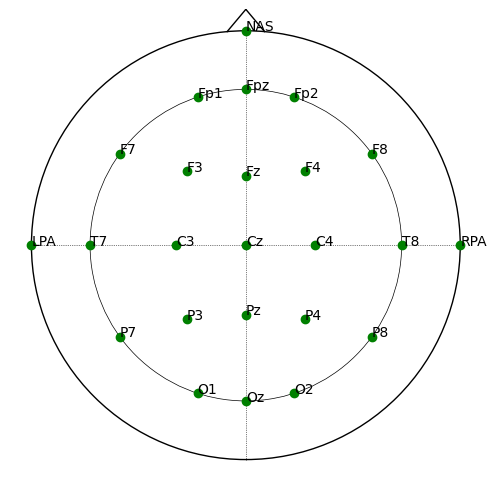

In [6]:
fig, ax = plot_coords(
    coords, scatter_kwargs={"color": "g"}, text_kwargs={"fontsize": 10}
)

fig

Notice that the "landmarks" ``NAS``, ``LPA``, and ``RPA`` are included. We can drop
these by passing ``drop_landmarks=True`` to :func:`get_elec_coords`:



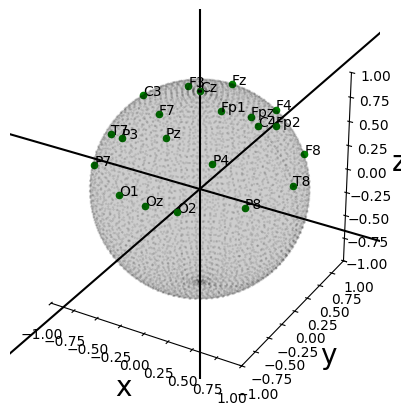

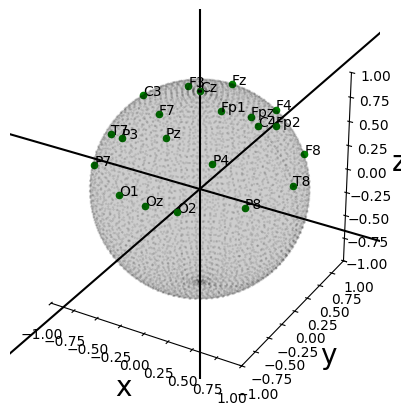

In [7]:
coords = get_elec_coords(
    system="1020",
    drop_landmarks=True,
    dim="3d",
)

fig, ax = plot_coords(
    coords, scatter_kwargs={"color": "g"}, text_kwargs={"fontsize": 10}
)

fig

Often, we might have a list of electrode names that we would like to plot. For
example, let's assume we have the following 64 channel labels (based on the 10-05
system):



In [9]:
chans = """Fp1 AF7 AF3 F1 F3 F5 F7 Fp2 AF8 AF4 F2 F4 F6 F8 FT7 FC5 FC3
FC1 C1 C3 C5 T7 TP7 CP5 CP3 CP1 FT8 FC6 FC4 FC2 C2 C4 C6 T8 TP8 CP6 CP4
CP2 P1 P3 P5 P7 P9 PO7 PO3 O1 P2 P4 P6 P8 P10 PO8 PO4 O2 Iz Oz POz Pz
Fz AFz Fpz CPz Cz FCz""".split()

Many experiments aggregate electrodes into regions of interest (ROIs), which we could
visualize with different colors. Let's get their coordinates first:



In [10]:
coords = get_elec_coords(elec_names=chans)

In [11]:
coords

,label,x,y
0,Fp1,-0.224523,0.690985
1,AF7,-0.427044,0.587853
2,AF3,-0.206710,0.527407
3,F1,-0.134926,0.330158
4,F3,-0.274417,0.346683
...,...,...,...
59,AFz,0.000000,0.509510
60,Fpz,0.000000,0.726585
61,CPz,0.000000,-0.158372
62,Cz,0.000000,0.000000


Now we specifiy individual colors using the ``scatter_kwargs``` argument. We create a
list of 64 colors corresponding to our 64 coordinates (in the original order as
provided by ``chans``):



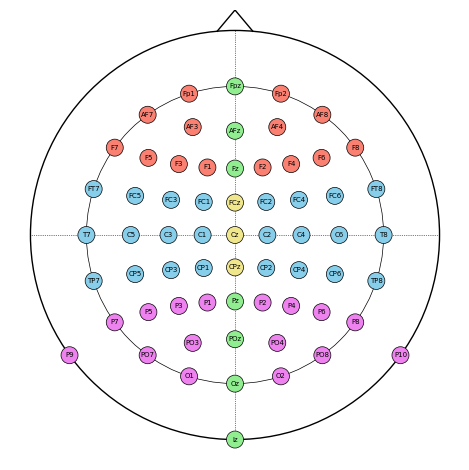

In [33]:
fig

We can also plot in 3D. Let's pick a system with more electrodes now:



In [13]:
"""Visualization utilities."""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from eeg_positions.config import RADIUS_INNER_CONTOUR
from eeg_positions.utils import _get_coords_on_circle


def _plot_2d_head(radius_inner_contour=None, show_axis=False):
    """Plot a head in 2D.

    Parameters
    ----------
    radius_inner_contour : int | float | None
        If int or float, draw a circle with that radius to visualize an inner
        contour line. Defaults to None, not drawing a circle. Can instead also
        be conveniently set to ``eeg_positions.config.RADIUS_INNER_CONTOUR``,
        which is the Fpz-T8-Oz-T7 contour line.
    show_axis : bool
        Whether or not to show the coordinate system x- and y-axes. Defaults to False.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The Figure object.
    ax : matplotlib.axes.Axes
        The Axes object.

    """
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.axes.set_aspect("equal")
    plt.xlabel("x")
    plt.ylabel("y")

    head_radius = 0.9
    linewidth = 0.5

    # Draw head shape
    head_shape = plt.Circle(
        (0, 0), head_radius, color="k", fill=False, linewidth=linewidth
    )
    ax.add_artist(head_shape)

    if radius_inner_contour is not None:
        head_shape = plt.Circle(
            (0, 0), radius_inner_contour, color="k", fill=False, linewidth=linewidth / 2
        )
        ax.add_artist(head_shape)

    # Draw nose
    nose_width = 5
    nose_base_l = _get_coords_on_circle(r=head_radius, steps=nose_width)[-1]
    nose_base_r = _get_coords_on_circle(r=head_radius, steps=nose_width)[1]
    nose_tip = 0.95
    ax.plot((nose_base_l[0], 0), (nose_base_l[1], nose_tip), "k", linewidth=linewidth)
    ax.plot((nose_base_r[0], 0), (nose_base_r[1], nose_tip), "k", linewidth=linewidth)

    ax.vlines(
        x=0,
        ymin=-1,
        ymax=1,
        color="black",
        linewidth=linewidth / 2,
        linestyles="dotted",
    )
    ax.hlines(
        y=0,
        xmin=-1,
        xmax=1,
        color="black",
        linewidth=linewidth / 2,
        linestyles="dotted",
    )

    # Adjust limits
    ax.set_xlim([-head_radius * 1.1, head_radius * 1.1])
    ax.set_ylim([-head_radius * 1.18, head_radius * 1.1])

    fig.set_layout_engine("constrained")
    if not show_axis:
        ax.set_axis_off()

    return fig, ax


def plot_coords_2(coords, scatter_kwargs={}, text_kwargs={}):
    """Plot standard EEG electrode coordinates.

    Parameters
    ----------
    coords : pandas.DataFrame
        The standard EEG electrode coordinates as computed on a sphere.
        A pandas DataFrame object with the columns ``"label"``, ``"x"``,
        ``"y"``, and optionally ``"z"``.
    scatter_kwargs : dict
        Optional keyword arguments to be passed to the
        :meth:`matplotlib.axes.Axes.scatter`
        or its 3D variant, depending on the dimensions of `coords`.
    text_kwargs : dict
        Optional keyword arguments to be passed to the
        :meth:`matplotlib.axes.Axes.text`.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The Figure object.
    ax : matplotlib.axes.Axes
        The Axes object.

    """
    # input check
    if not isinstance(coords, pd.DataFrame):
        raise ValueError("`coords` must be a pandas DataFrame object.")
    else:
        for colname in ["label", "x", "y"]:
            if colname not in coords.columns:
                raise ValueError(f"`coords` does not have a required column {colname}.")
    # update kwargs
    scatter_settings = dict()
    scatter_settings.update(scatter_kwargs)
    text_settings = dict(fontsize=6)
    text_settings.update(text_kwargs)

    fig, ax = _plot_2d_head(RADIUS_INNER_CONTOUR)
    ax.scatter(coords["x"], coords["y"], zorder=2.5, **scatter_settings)
    for _, row in coords.iterrows():
        ax.text(row["x"], row["y"], row["label"], **text_settings)
    return fig, ax

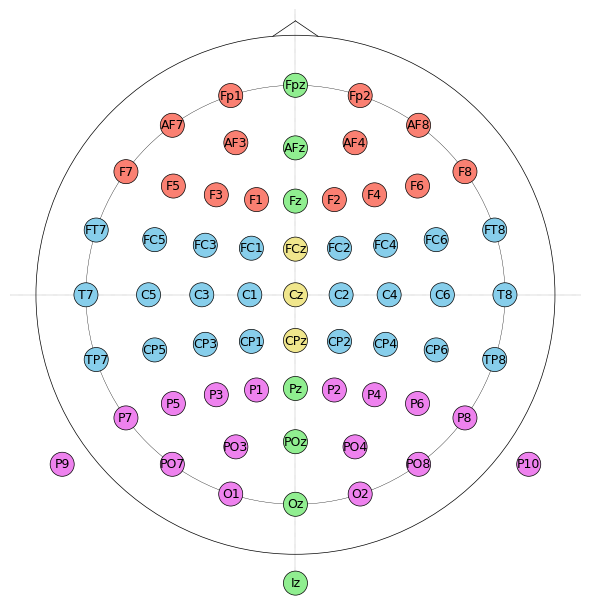

In [14]:
colors = (
    ["salmon"] * 14
    + ["skyblue"] * 24
    + ["violet"] * 16
    + ["lightgreen"] * 7
    + ["khaki"] * 3
)

fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 300,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.5,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 9,  # smaller font size
    },
)

In [15]:
chans = """Fp1 AF7 AF3 F1 F3 F5 F7 Fp2 AF8 AF4 F2 F4 F6 F8 FT7 FC5 FC3
FC1 C1 C3 C5 T7 TP7 CP5 CP3 CP1 FT8 FC6 FC4 FC2 C2 C4 C6 T8 TP8 CP6 CP4
CP2 P1 P3 P5 P7 P9 PO7 PO3 O1 P2 P4 P6 P8 P10 PO8 PO4 O2 Iz Oz POz Pz
Fz AFz Fpz CPz Cz FCz""".split()
coords = get_elec_coords(elec_names=chans)

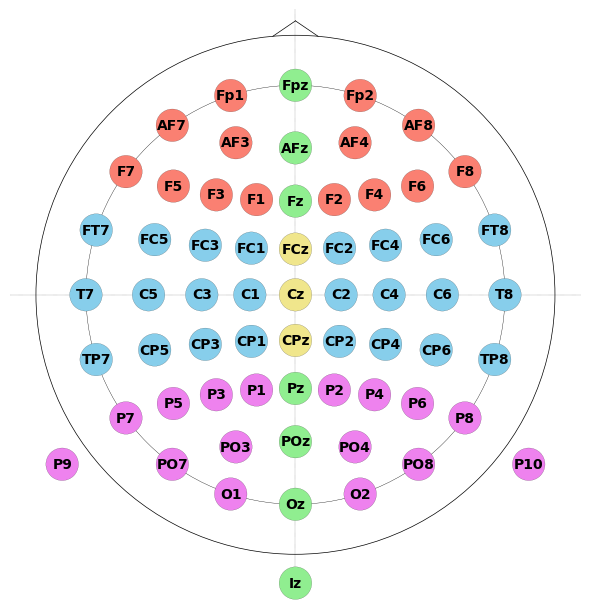

In [16]:
colors = (
    ["salmon"] * 14
    + ["skyblue"] * 24
    + ["violet"] * 16
    + ["lightgreen"] * 7
    + ["khaki"] * 3
)

fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 550,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 10,  # smaller font size
        "fontweight": "bold",  # make font bold
    },
)
fig.savefig("64_electrode_positions.eps", format="eps")

In [32]:
chans = """AF3 F7 F3 AF4 F8 F4 FC5 FC6 T7 T8 P7 P8 O1 O2""".split()
coords = get_elec_coords(elec_names=chans)

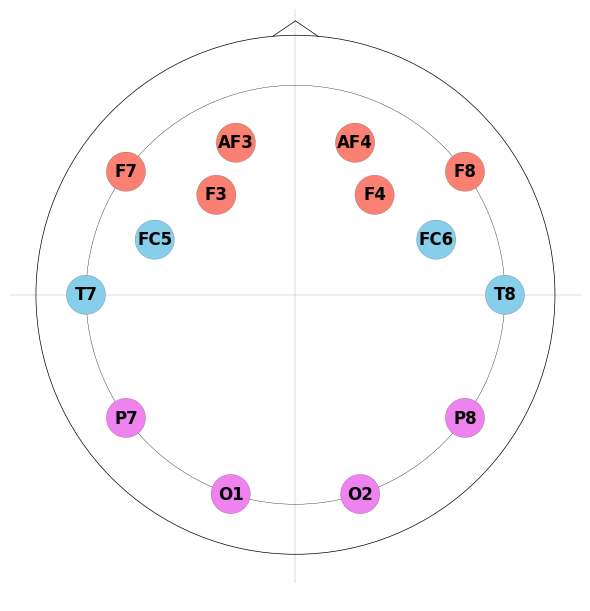

In [33]:
colors = (
    ["salmon"] * 6
    + ["skyblue"] * 4
    + ["violet"] * 4
)

fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 800,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 12,  # smaller font siz
        "fontweight": "bold",  # make font bold
    },
)
fig.savefig("epoc_position.eps", format="eps")

When using these commands from an interactive Python session, try to set
the IPython magic ``%matplotlib`` or ``%matplotlib qt``, which will allow you to
freely view the 3D plot and rotate the camera.



In [34]:
chans = """Fz Pz POz FCz Cz CPz FC3 FC1 FC2 FC4 C5 C3 C1 C2 C4 C6 CP3 CP1 CP2 CP4 P1 P2""".split()
coords = get_elec_coords(elec_names=chans)

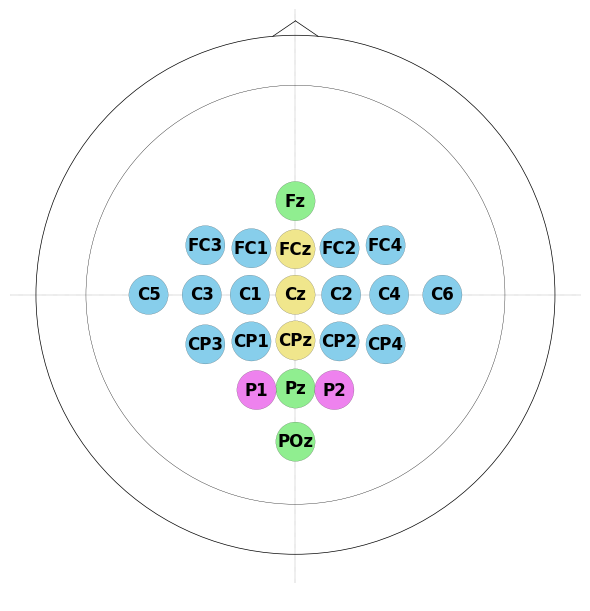

In [35]:
# colors = (
#     ["salmon"] * 14
#     + ["skyblue"] * 24
#     + ["violet"] * 16
#     + ["lightgreen"] * 7
#     + ["khaki"] * 3
# )

colors = (
    ["lightgreen"] * 3
    + ["khaki"] * 3
    + ["skyblue"] * 14
    + ["violet"] * 2
)

fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 800,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 12,  # smaller font siz
        "fontweight": "bold",  # make font bold
    },
)
fig.savefig("BCICIV_position.eps", format="eps")

In [36]:
chans = """Fp1 Fp2 F3 F7 F8 F4 Fz Pz T7 T8 C3 C4 P3 P4 O1 O2 P6 P5 Cz""".split()
coords = get_elec_coords(elec_names=chans)

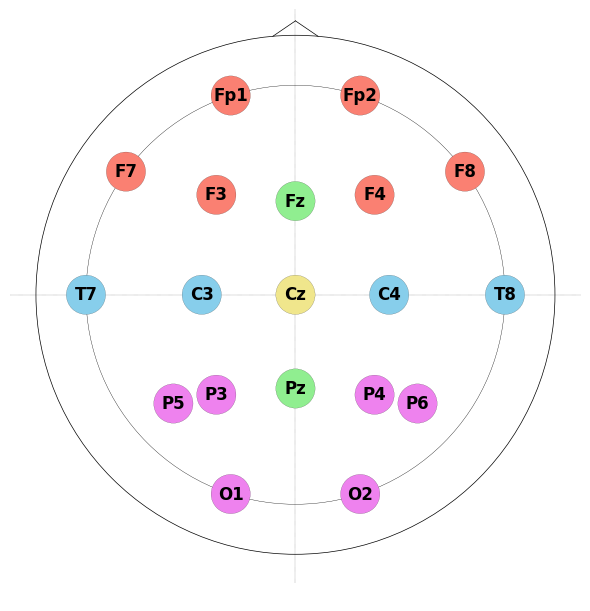

In [37]:
colors = (
    ["salmon"] * 6
    + ["lightgreen"] * 2
    + ["skyblue"] * 4
    + ["violet"] * 6
    + ["khaki"] * 1
)
fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 800,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 12,  # smaller font siz
        "fontweight": "bold",  # make font bold
    },
)
fig.savefig("Temple_position.eps", format="eps")

In [39]:
chans = ['Oz','O1','O2','POz','PO3','PO4','PO7','PO8']
coords = get_elec_coords(elec_names=chans)

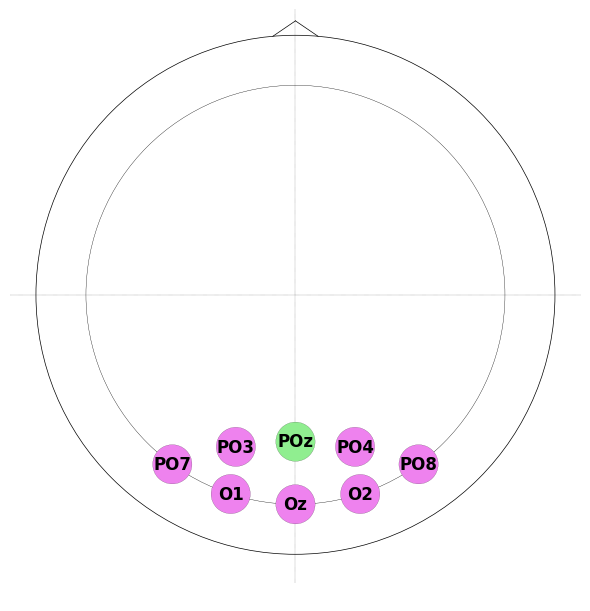

In [42]:
colors = (
    ["violet"] * 3
    + ["lightgreen"] * 1
    + ["violet"] * 4
)
fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 800,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 12,  # smaller font siz
        "fontweight": "bold",  # make font bold
    },
)
fig.savefig("SSVEP_position.eps", format="eps")

In [271]:
coords.to_csv("electrode_positions.csv", index=False)

In [2]:
import pandas as pd
coords = pd.read_csv("electrode_positions.csv")
coords.head(10)

,label,x,y
0,Fp1,-0.224523,0.690985
1,AF7,-0.427044,0.587853
2,AF3,-0.206710,0.527407
3,F1,-0.134926,0.330158
4,F3,-0.274417,0.346683
5,F5,-0.423389,0.377139
6,F7,-0.587853,0.427044
7,Fp2,0.224523,0.690985
8,AF8,0.427044,0.587853
9,AF4,0.206710,0.527407


In [4]:
coords['x'] = (coords['x']+0.8) *5
coords['y'] = (coords['y']+1)* 5

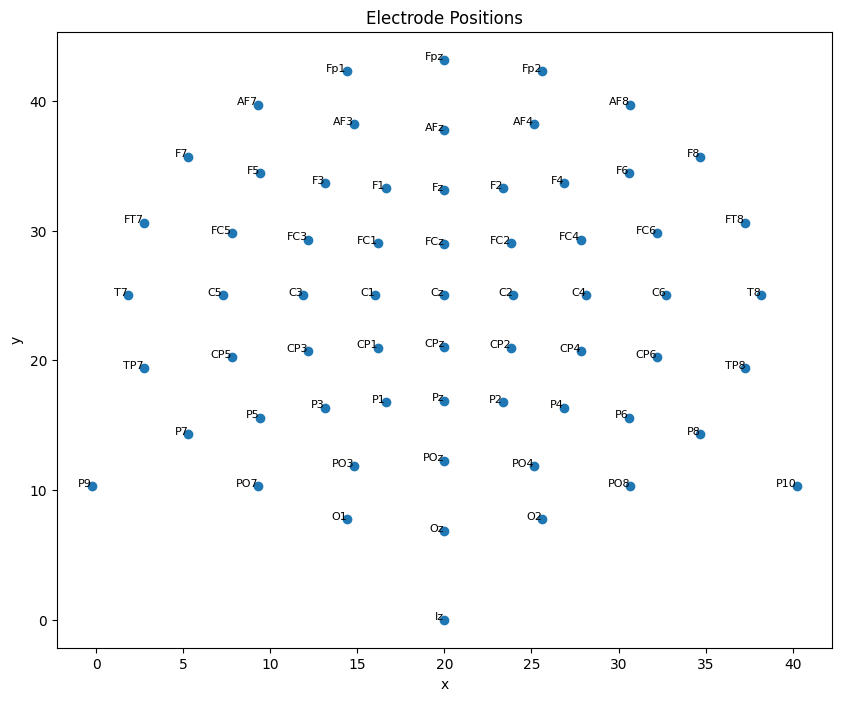

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.scatter(coords['x']*5, coords['y']*5)

for i, label in enumerate(coords['label']):
    plt.annotate(label, (coords['x'][i]*5, coords['y'][i]*5), fontsize=8, ha='right')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Electrode Positions')
plt.show()

In [7]:
import numpy as np

def positional_encoding_2d(coords, d):
    """
    Generate sinusoidal positional embeddings for a list of (x, y) coordinates.
    
    Args:
        coords: List of (x, y) tuples representing positions.
        d: Embedding dimension (must be even).

    Returns:
        pos_embedding: (N, d) matrix of positional embeddings.
    """
    N = len(coords)
    pos_embedding = np.zeros((N, d))
    
    for idx, (x, y) in enumerate(coords):
        for k in range(d // 4):  # Half for x, half for y
            pos_embedding[idx, 4*k] = np.sin(x / (5 ** (4*k / d)))
            pos_embedding[idx, 4*k + 1] = np.cos(x / (5 ** (4*k / d)))
            pos_embedding[idx, 4*k + 2] = np.sin(y / (5 ** (4*k / d)))
            pos_embedding[idx, 4*k + 3] = np.cos(y / (5 ** (4*k / d)))
    
    return pos_embedding



In [8]:
# Example usage with an unordered list of (x, y) coordinates
# new_coords = [(x, y) for x, y in zip(x_rank, y_rank)]
new_coords = [(x, y) for x, y in zip(coords['x'], coords['y'])]
d = 16
pos_embedding = positional_encoding_2d(new_coords, d)
print("Positional Embedding Shape:", pos_embedding.shape)

Positional Embedding Shape: (64, 16)


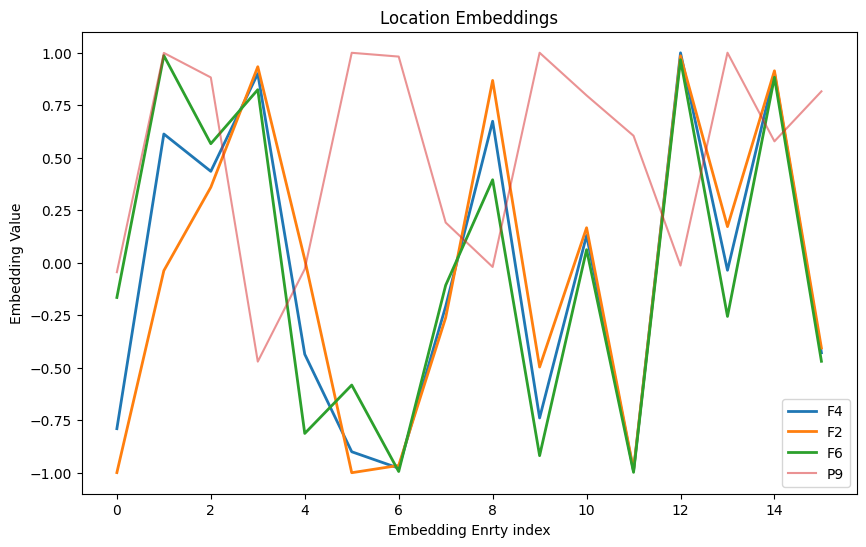

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(pos_embedding[11], label='F4', linewidth=2)
plt.plot(pos_embedding[10], label='F2', linewidth=2)
plt.plot(pos_embedding[12], label='F6', linewidth=2)
plt.plot(pos_embedding[42], label='P9', alpha=0.5)
plt.xlabel('Embedding Enrty index')
plt.ylabel('Embedding Value')
plt.title('Location Embeddings')
plt.legend()
plt.show()

In [242]:
coords['label'][51]

'PO8'

In [19]:
F4_similarity = np.dot(pos_embedding[11], pos_embedding.T)
F4_similarity[11]

8.0

In [13]:
chans = """Fp1 AF7 AF3 F1 F3 F5 F7 Fp2 AF8 AF4 F2 F4 F6 F8 FT7 FC5 FC3
FC1 C1 C3 C5 T7 TP7 CP5 CP3 CP1 FT8 FC6 FC4 FC2 C2 C4 C6 T8 TP8 CP6 CP4
CP2 P1 P3 P5 P7 P9 PO7 PO3 O1 P2 P4 P6 P8 P10 PO8 PO4 O2 Iz Oz POz Pz
Fz AFz Fpz CPz Cz FCz""".split()
coords = get_elec_coords(elec_names=chans)

/home/navid/Desktop/Monash/Emotiv/Research/25.01.07 EEG-X/.venv/lib/python3.8/site-packages/eeg_positions/utils.py:242: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(df[df["label"] == label].x)
/home/navid/Desktop/Monash/Emotiv/Research/25.01.07 EEG-X/.venv/lib/python3.8/site-packages/eeg_positions/utils.py:243: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(df[df["label"] == label].y)
/home/navid/Desktop/Monash/Emotiv/Research/25.01.07 EEG-X/.venv/lib/python3.8/site-packages/eeg_positions/utils.py:244: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  z = float(df[df["label"] == label].z)
/home/navid/Desktop/Monash/Emotiv/Research/25.01.07 EEG-X/.venv/lib/python3.8/site-packages

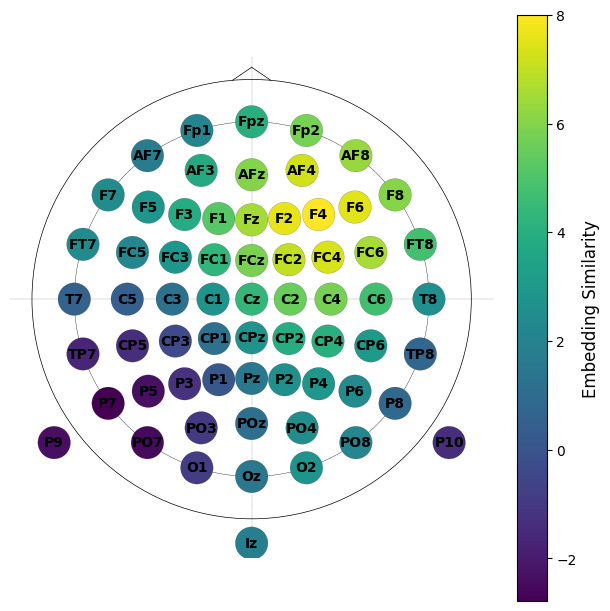

In [24]:
import matplotlib.colors as mcolors

# Normalize F4_similarity to range between 0 and 1
norm = mcolors.Normalize(vmin=F4_similarity.min(), vmax=F4_similarity.max())

# Create a colormap
cmap = plt.get_cmap('viridis')

# Map the normalized similarity values to colors (darker color for higher similarity)
colors = [cmap(norm(value)) for value in F4_similarity]

fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 550,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 10,  # smaller font size
        "fontweight": "bold",  # make font bold
    },
)

# Add a colorbar to the plot
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Embedding Similarity', fontsize=12)

fig.savefig("F4_positions_similarity.eps", format="eps")

In [25]:
P3_similarity = np.dot(pos_embedding[39], pos_embedding.T)

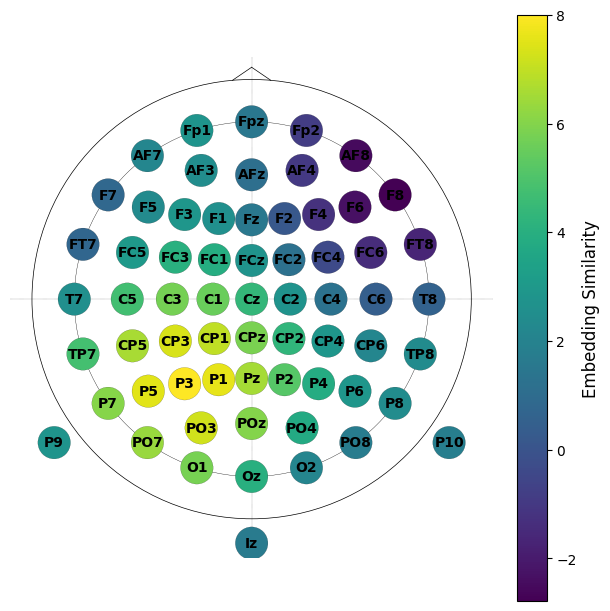

In [31]:
import matplotlib.colors as mcolors

# Normalize F4_similarity to range between 0 and 1
norm = mcolors.Normalize(vmin=P3_similarity.min(), vmax=P3_similarity.max())

# Create a colormap
cmap = plt.get_cmap('viridis')

# Map the normalized similarity values to colors (darker color for higher similarity)
colors = [cmap(norm(value)) for value in P3_similarity]

fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 550,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 10,  # smaller font size
        "fontweight": "bold",  # make font bold
    },
)

# Add a colorbar to the plot
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Embedding Similarity', fontsize=12)

fig.savefig("P3_positions_similarity.eps", format="eps")

In [28]:
F7_similarity = np.dot(pos_embedding[6], pos_embedding.T)

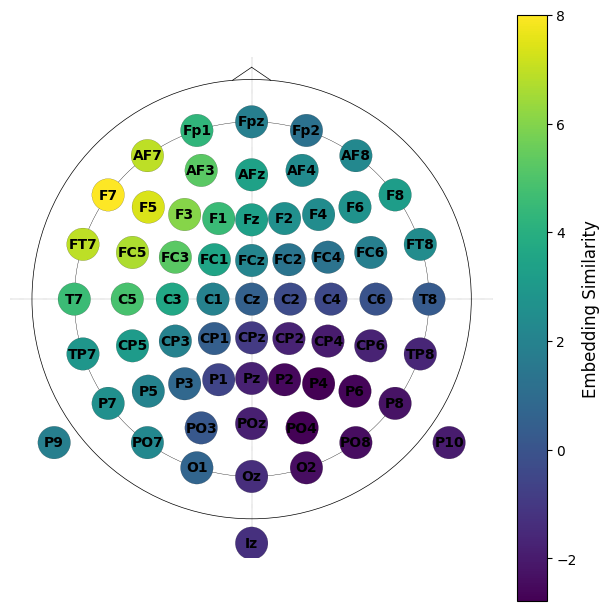

In [30]:
import matplotlib.colors as mcolors

# Normalize F4_similarity to range between 0 and 1
norm = mcolors.Normalize(vmin=F7_similarity.min(), vmax=F7_similarity.max())

# Create a colormap
cmap = plt.get_cmap('viridis')

# Map the normalized similarity values to colors (darker color for higher similarity)
colors = [cmap(norm(value)) for value in F7_similarity]

fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 550,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 10,  # smaller font size
        "fontweight": "bold",  # make font bold
    },
)

# Add a colorbar to the plot
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Embedding Similarity', fontsize=12)

fig.savefig("F7_positions_similarity.eps", format="eps")

In [280]:
F4_similarity = np.dot(pos_embedding[11], pos_embedding.T)
top_10_indices = F4_similarity.argsort()[-15:][::-1]
top_10_labels = coords['label'].iloc[top_10_indices]
print("Top 10 indices:", top_10_indices)
print("Top 10 labels:", top_10_labels.values)

Top 10 indices: [11 10 12 28  9 29 27 58  8 13 59 63  7 31 30]
Top 10 labels: ['F4' 'F2' 'F6' 'FC4' 'AF4' 'FC2' 'FC6' 'Fz' 'AF8' 'F8' 'AFz' 'FCz' 'Fp2'
 'C4' 'C2']


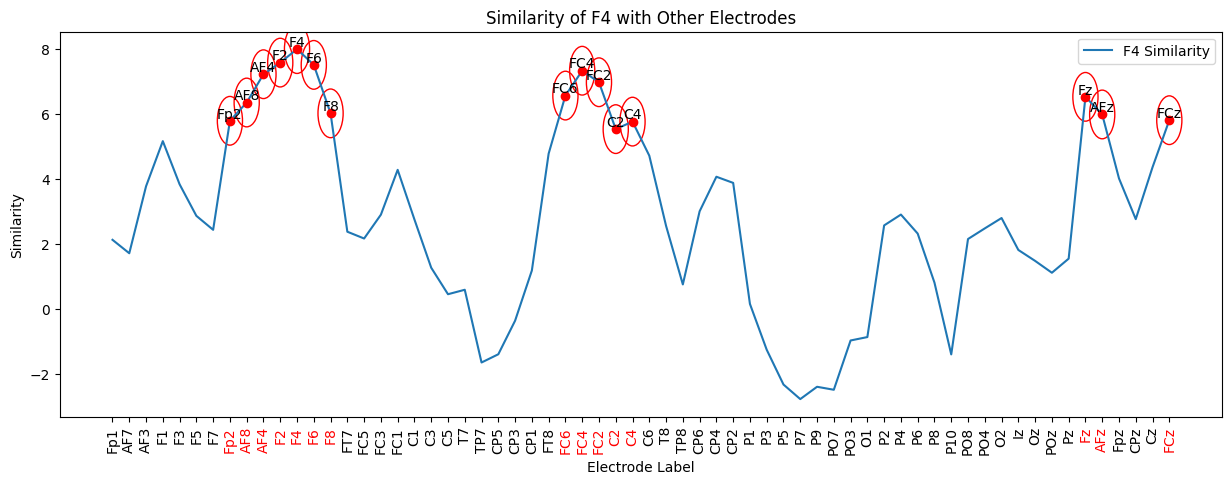

In [293]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(F2_similarity, label='F4 Similarity')
plt.xlabel('Electrode Label')
plt.ylabel('Similarity')
plt.title('Similarity of F4 with Other Electrodes')
plt.xticks(ticks=range(len(coords)), labels=coords['label'], rotation=90)

for idx in top_10_indices:
    plt.gca().get_xticklabels()[idx].set_color('red')

# Highlight top 10 indices
for idx in top_10_indices:
    plt.plot(idx, F2_similarity[idx], 'ro')  # red dots
    circle = plt.Circle((idx, F2_similarity[idx]), 0.75, color='red', fill=False)
    plt.gca().add_artist(circle)
    plt.text(idx, F2_similarity[idx], coords['label'][idx], color='black', fontsize=10, ha='center', va='bottom')

plt.legend()
plt.show()


In [296]:
epoch14_electrodes = ['af3', 'f7', 'f3', 'fc5', 't7', 'p7', 'o1', 'o2', 'p8', 't8', 'fc6', 'f4', 'f8', 'af4']
coords['label'] = coords['label'].str.lower()
epoch14_electrode_indices = coords[coords['label'].isin(epoch14_electrodes)].index.tolist()
epoch14_electrode_embeddings = pos_embedding[epoch14_electrode_indices]

In [304]:
F3_similarity = np.dot(epoch14_electrode_embeddings[4], epoch14_electrode_embeddings.T)
top_10_indices = F3_similarity.argsort()[-10:][::-1]
epoch14_electrodes = np.array(epoch14_electrodes)
top_10_labels = epoch14_electrodes[top_10_indices]
print("Top 10 indices:", top_10_indices)
print("Top 10 labels:", top_10_labels)

Top 10 indices: [ 4  3  8  5  1  0 13  9  2  6]
Top 10 labels: ['t7' 'fc5' 'p8' 'p7' 'f7' 'af3' 'af4' 't8' 'f3' 'o1']
